# 1er Parcial 2C 2026 — Resolución y contraste con las clases

Cada ejercicio: enunciado, resolución justificada, verificación en código y **contraste** con las notebooks de `src/notebooks/explained/`. Las fotos originales están en `../raw/`.

> Las citas a celdas usan los índices del JSON de cada notebook explicada; pueden diferir de la numeración "celdas x–y" de las propias notebooks. El Ej. 7 no tiene material de clase.

| Ej. | Tema | Clase de referencia |
|---|---|---|
| 1 | SVD | 3 |
| 2 | EPE con pérdida absoluta | 1 |
| 3 | Ridge por datos aumentados / Lasso | 4 (y 5) |
| 4 | Coordinate descent con predictores idénticos | 5 |
| 5 | Regresión polinómica estandarizada | 2 y 4 |
| 6 | Predictores ortogonales | 2–5 |
| 7 | Breiman / Donoho / Efron | — |

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Ejercicio 1 — SVD de una matriz 2×2

Sea $\mathbf{X}$ la matriz de observaciones

$$\mathbf{X}=\begin{pmatrix}0 & -\tfrac12\\ 3 & 0\end{pmatrix}.$$

Sus valores singulares son $\tfrac12$ y $3$, y las matrices

$$U=\begin{pmatrix}0 & -1\\ -1 & 0\end{pmatrix},\qquad V^T=\begin{pmatrix}-1 & 0\\ 0 & 1\end{pmatrix},$$

productos de la descomposición en valores singulares de $\mathbf{X}$.

Indicá si cada afirmación es verdadera (V) o falsa (F). Si es falsa, calculá el producto correspondiente.

| Afirmación | V/F | Cálculo (si corresponde) |
|---|---|---|
| $U^TU=I$ | | |
| $UU^T=I$ | | |
| $V^TV=I$ | | |
| $VV^T=I$ | | |
| $DV^T=X^T$ | | |
| $V^TD=X^T$ | | |
| $UDV^T=X$ | | |
| $V^TDU=X$ | | |

![Foto del examen](../raw/p1_ej1.jpeg)

### Resolución

**Paso 0: quién es $D$.** $D$ es la diagonal de los valores singulares. Por convención de la materia van ordenados de mayor a menor, $d_1\ge d_2\ge 0$, así que

$$D=\begin{pmatrix}3&0\\0&\tfrac12\end{pmatrix}.$$

El enunciado nombra los valores como "$\tfrac12$ y $3$", pero *ese orden no sirve*: con $D=\mathrm{diag}(\tfrac12,3)$ el producto $UDV^T$ da $\begin{pmatrix}0&-3\\ \tfrac12&0\end{pmatrix}\neq X$. Con $D=\mathrm{diag}(3,\tfrac12)$ sí cierra (paso 3). Que $U$ y $V$ no estén cambiadas de lugar es justo lo que fija el orden.

**Paso 1: $U$ y $V$ son ortogonales.** Las columnas de $U$ son $(0,-1)$ y $(-1,0)$: ortogonales y de norma 1. Las de $V$ (filas de $V^T$) son $(-1,0)$ y $(0,1)$: idem. Son cuadradas, así que $Q^TQ=QQ^T=I$ para las dos.

- $U^TU=I$: **V**
- $UU^T=I$: **V**
- $V^TV=I$: **V**
- $VV^T=I$: **V**

(En la clase la SVD es *thin* y $UU^T\neq I$ cuando $N>p$. Acá $\mathbf{X}$ es cuadrada, no hay diferencia.)

**Paso 2: $DV^T$ y $V^TD$.** Como $D$ es diagonal, multiplicarla a izquierda escala filas y a derecha escala columnas:

$$DV^T=\begin{pmatrix}3&0\\0&\tfrac12\end{pmatrix}\begin{pmatrix}-1&0\\0&1\end{pmatrix}=\begin{pmatrix}-3&0\\0&\tfrac12\end{pmatrix},\qquad V^TD=\begin{pmatrix}-3&0\\0&\tfrac12\end{pmatrix}.$$

Ambas dan lo mismo (diagonal por diagonal conmuta) y $X^T=\begin{pmatrix}0&3\\-\tfrac12&0\end{pmatrix}$. Entonces:

- $DV^T=X^T$: **F**, da $\begin{pmatrix}-3&0\\0&\tfrac12\end{pmatrix}$
- $V^TD=X^T$: **F**, da $\begin{pmatrix}-3&0\\0&\tfrac12\end{pmatrix}$

**Paso 3: $UDV^T$.**

$$UD=\begin{pmatrix}0&-\tfrac12\\-3&0\end{pmatrix},\qquad UDV^T=\begin{pmatrix}0&-\tfrac12\\-3&0\end{pmatrix}\begin{pmatrix}-1&0\\0&1\end{pmatrix}=\begin{pmatrix}0&-\tfrac12\\3&0\end{pmatrix}=X.$$

- $UDV^T=X$: **V**

**Paso 4: $V^TDU$.** Ya tenemos $V^TD$:

$$V^TDU=\begin{pmatrix}-3&0\\0&\tfrac12\end{pmatrix}\begin{pmatrix}0&-1\\-1&0\end{pmatrix}=\begin{pmatrix}0&3\\-\tfrac12&0\end{pmatrix}=X^T\neq X.$$

- $V^TDU=X$: **F**, da $\begin{pmatrix}0&3\\-\tfrac12&0\end{pmatrix}$ (que es $X^T$)

Esto no es casualidad: de $X=UDV^T$ sale $X^T=VDU^T$, y acá $U$ y $V$ resultan simétricas, así que $V^TDU=VDU^T=X^T$.

**Resumen:** V, V, V, V, F, F, V, F.

In [2]:
import numpy as np

X  = np.array([[0, -1/2], [3, 0]])
U  = np.array([[0, -1], [-1, 0]])
Vt = np.array([[-1, 0], [0, 1]])
V  = Vt.T
print("valores singulares de X:", np.linalg.svd(X, compute_uv=False))  # 3 y 1/2
I = np.eye(2)
for D in (np.diag([3, 1/2]), np.diag([1/2, 3])):
    print("\nD =", np.diag(D))
    print("UDVt == X ?", np.allclose(U @ D @ Vt, X))
D = np.diag([3, 1/2])   # orden de la clase: d1 >= d2
pruebas = {
    "UtU = I":  (U.T @ U, I),   "UUt = I":  (U @ U.T, I),
    "VtV = I":  (Vt @ V, I),    "VVt = I":  (V @ Vt, I),
    "DVt = Xt": (D @ Vt, X.T),  "VtD = Xt": (Vt @ D, X.T),
    "UDVt = X": (U @ D @ Vt, X), "VtDU = X": (Vt @ D @ U, X),
}
print()
for nombre, (prod, objetivo) in pruebas.items():
    print(nombre, "->", "V" if np.allclose(prod, objetivo) else "F")
    if not np.allclose(prod, objetivo): print(prod)
print("\nXt =\n", X.T)

valores singulares de X: [3.  0.5]

D = [3.  0.5]
UDVt == X ? True

D = [0.5 3. ]
UDVt == X ? False

UtU = I -> V
UUt = I -> V
VtV = I -> V
VVt = I -> V
DVt = Xt -> F
[[-3.   0. ]
 [ 0.   0.5]]
VtD = Xt -> F
[[-3.   0. ]
 [ 0.   0.5]]
UDVt = X -> V
VtDU = X -> F
[[ 0.   3. ]
 [-0.5  0. ]]

Xt =
 [[ 0.   3. ]
 [-0.5  0. ]]


### Contraste con las clases

- **Definición y forma de $D$, $U$, $V$:** `3_regresion_lineal_maxima_verosimilitud_svd.ipynb`, §4 "SVD: qué es y por qué 'cualquier matriz'", subsección *Formalizándolo*: $\mathbf{X}=UDV^T$, $D$ diagonal con $d_1\ge d_2\ge\dots\ge d_p\ge 0$ (de ahí el orden $\mathrm{diag}(3,\tfrac12)$), y $V^TV=VV^T=I_p$. Lo mismo aparece en §0 "Notación y convenciones".
- **Ortogonal vs. semi-ortogonal:** misma sección, párrafo *Ortogonal vs. semi-ortogonal*. Para $U$ de $N\times p$ con $N>p$ vale $U^TU=I_p$ pero $UU^T\neq I_N$ (es la matriz sombrero, §6). En este ejercicio $N=p=2$, entonces $U$ es cuadrada y $UU^T=I$ también. Los ítems 1 y 2 son verdaderos por eso, no por regla general.
- **No unicidad:** misma sección, punto *No unicidad*: se puede cambiar el signo de una columna de $U$ y de la de $V$ a la vez. Explica los signos negativos de $U$ y $V^T$ del enunciado, y que el producto $UDV^T$ siga dando $X$.
- **Transpuesta de $X$:** §6 "SVD aplicada a regresión lineal", subsección *Formalizándolo*: $\mathbf{X}^T=VDU^T$. Es la identidad que el ítem $V^TDU=X$ intenta imitar, pero con $V^T$ y $U$ en vez de $V$ y $U^T$ (y sin transponer el resultado).
- **Notas:** `notes/descomposicion-matrices-svd.md`, §5.1 (escribe $A=U\Sigma V^T$ con $\sigma_1\ge\sigma_2\ge\dots\ge 0$; $\Sigma$ es la $D$ de las clases) y §5.2 (los $v_i$ son autovectores de $A^TA$, $\sigma_i=\sqrt{\lambda_i}$).

**Discrepancia del enunciado.** Dice "valores singulares $\tfrac12$ y $3$", en ese orden, pero la convención de la materia los ordena de mayor a menor. Si se arma $D=\mathrm{diag}(\tfrac12,3)$ literalmente, $UDV^T\neq X$ y el ítem 7 pasaría a ser falso. Está pensado con $D=\mathrm{diag}(3,\tfrac12)$: solo así $UDV^T=X$.

### Cómo reconocerlo en el examen

- **Qué pudiste contestar mal:** dar por buenas las ocho igualdades porque "U, V son ortogonales". Las cuatro primeras sí; las de $D$ no.
- **La señal:** cuando un producto mezcla $D$ con $V^T$ o con $U$ en orden distinto al $UDV^T$, hay que multiplicar. $D$ no conmuta con nada.
- **Chequeo de 30 segundos:** multiplicá $UDV^T$ primero. Si da $X$, el orden de $D$ (mayor a menor) queda confirmado y los otros productos se calculan con esa $D$.

## Ejercicio 2 — Pérdida absoluta: el óptimo es la mediana

**Enunciado.** En clase vimos que, bajo la pérdida cuadrática $L(Y,f(X))=(Y-f(X))^2$, la predicción que minimiza el EPE es la media condicional, $f(x)=\mathbb{E}[Y\mid X=x]$. Supongamos ahora que usamos la pérdida absoluta, $L(Y,f(X))=|Y-f(X)|$.

a) Escribí el EPE y explicá en una línea por qué se puede minimizar punto a punto.

b) Para un $x$ fijo, planteá el problema de minimización sobre $c=f(x)$ y derivá la condición de óptimo.

c) ¿Qué estadístico de $p(Y\mid X=x)$ resulta ser la predicción óptima?

d) ¿En qué situación preferirías esta pérdida a la cuadrática? Respondé en una línea.

### Resolución

**a) EPE y minimización punto a punto.** Con la pérdida absoluta:

$$EPE(f)=\mathbb{E}\big[|Y-f(X)|\big]=\int\!\!\int |y-f(x)|\,p(y\mid x)\,p(x)\,dy\,dx=\mathbb{E}_X\Big[\mathbb{E}_{Y\mid X}\big[|Y-f(X)|\,\big|\,X\big]\Big].$$

El valor $f(x)$ solo aparece en el término del punto $x$, y cada término se pondera con $p(x)\ge 0$. Entonces el EPE es una integral de términos independientes y no negativos, y se minimiza minimizando cada uno por separado.

**b) Problema en $x$ fijo.** Sea $c=f(x)$ y $F(c)=P(Y\le c\mid x)$ la acumulada condicional. Hay que resolver

$$\min_{c\in\mathbb{R}}\; g(c),\qquad g(c)=\mathbb{E}\big[|Y-c|\mid X=x\big]=\int_{-\infty}^{c}(c-y)\,p(y\mid x)\,dy+\int_{c}^{\infty}(y-c)\,p(y\mid x)\,dy.$$

El integrando $|y-c|$ no es derivable en $y=c$, así que no se puede derivar adentro de la esperanza como con $(y-c)^2$. Se parte la integral en tramos y se deriva cada uno con Leibniz. Los términos de borde valen $(c-c)\,p(c\mid x)=0$, y queda:

$$g'(c)=\int_{-\infty}^{c}p(y\mid x)\,dy-\int_{c}^{\infty}p(y\mid x)\,dy=F(c)-\big(1-F(c)\big)=2F(c)-1.$$

Igualando a cero:

$$2F(c)-1=0\;\Longleftrightarrow\;P(Y\le c\mid x)=\tfrac12 .$$

Es un mínimo: $g'(c)=2F(c)-1$ crece con $c$ (va de $-1$ a $1$), así que $g$ es convexa ($g''(c)=2p(c\mid x)\ge0$).

Si $Y\mid x$ no tiene densidad (por ejemplo, es discreta), $g$ no es derivable en los saltos de $F$. Ahí se usan las derivadas laterales $g'_-(c)=2P(Y<c)-1$ y $g'_+(c)=2P(Y\le c)-1$. El punto $c$ es óptimo si y solo si $0\in[g'_-(c),\,g'_+(c)]$, es decir, si

$$P(Y<c\mid x)\le\tfrac12\le P(Y\le c\mid x).$$

Es la misma idea por tramos que pedía el Ejercicio 1 de la clase 2: el mínimo está donde la pendiente cambia de signo, no donde se anula.

**c) Estadístico óptimo.** $P(Y\le c\mid x)=\tfrac12$ es la definición de **mediana condicional**:

$$\boxed{\,f(x)=\operatorname{mediana}(Y\mid X=x)\,}$$

Con la pérdida cuadrática el óptimo era la media. Las dos coinciden solo si $p(y\mid x)$ es simétrica.

**d) Cuándo preferirla.** Cuando hay *outliers* o colas pesadas en $Y\mid x$ (o el error es Laplace): un dato extremo corre mucho la media y casi nada la mediana. El costo es que la pérdida no es diferenciable, no hay solución cerrada, y con errores gaussianos es menos eficiente.

### Verificación numérica

Tomamos un $x$ fijo con $Y\mid x$ log-normal (asimétrica, media $\approx 1{,}65$, mediana $=1$). Minimizamos el riesgo empírico sobre una grilla de $c$ con cada pérdida.

![Foto del examen](../raw/p2_ej2-3.jpeg)

argmin |.|  : 0.989 | mediana  : 0.994
argmin (.)^2: 1.644 | media    : 1.643
P(Y <= c*)  : 0.498


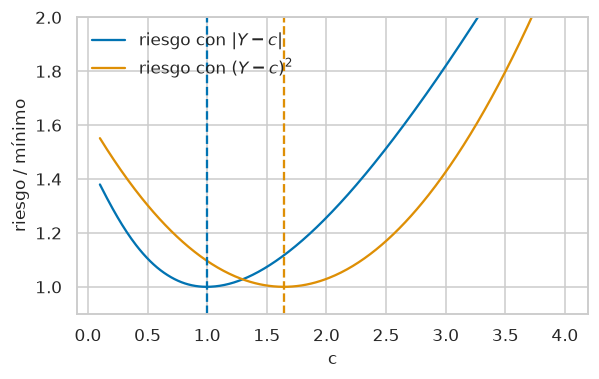

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
y = rng.lognormal(mean=0.0, sigma=1.0, size=20_000)      # Y | x asimétrica (x fijo)
grilla = np.linspace(0.1, 4, 400)                        # candidatos c = f(x)
riesgo_abs = np.array([np.mean(np.abs(y - c)) for c in grilla])
riesgo_cuad = np.array([np.mean((y - c) ** 2) for c in grilla])
print(f"argmin |.|  : {grilla[riesgo_abs.argmin()]:.3f} | mediana  : {np.median(y):.3f}")
print(f"argmin (.)^2: {grilla[riesgo_cuad.argmin()]:.3f} | media    : {y.mean():.3f}")
print(f"P(Y <= c*)  : {np.mean(y <= grilla[riesgo_abs.argmin()]):.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(grilla, riesgo_abs / riesgo_abs.min(), label="riesgo con $|Y-c|$")
ax.plot(grilla, riesgo_cuad / riesgo_cuad.min(), label="riesgo con $(Y-c)^2$")
ax.axvline(np.median(y), ls="--", c="C0"); ax.axvline(y.mean(), ls="--", c="C1")
ax.set_ylim(0.9, 2); ax.set_xlabel("c"); ax.set_ylabel("riesgo / mínimo"); ax.legend()
plt.show()

El mínimo de $\mathbb{E}|Y-c|$ cae en la mediana ($\approx 1$) y el de $\mathbb{E}(Y-c)^2$ en la media ($\approx 1{,}64$). Además $P(Y\le c^*)\approx 0{,}5$, como pedía la condición de óptimo. Ahora, la robustez (inciso d): agregamos un solo *outlier* a una muestra normal.

In [4]:
import numpy as np

rng = np.random.default_rng(1)
y = rng.normal(0, 1, 101)
for outlier in [None, 50.0]:
    yy = y.copy()
    if outlier: yy[0] = outlier
    print(f"outlier={outlier}: media={yy.mean():.3f}  mediana={np.median(yy):.3f}")

outlier=None: media=-0.079  mediana=0.028
outlier=50.0: media=0.412  mediana=0.028


Un solo dato en $50$ mueve la media de $-0{,}08$ a $0{,}41$. La mediana no se mueve.

### Contraste con las clases

- **a) Minimización punto a punto:** `1_intro_teoria_decision.ipynb`, sección *6. El mismo resultado, con la notación de Hastie: EPE y función de pérdida* (celda JSON 27, subtítulo "La minimización punto a punto"), y de nuevo en *8. Decisión en regresión: la media condicional* (celda 31), donde el argumento se repite para $(Y-f(X))^2$. La clase cita ESL §2.4.
- **b) Derivar por tramos:** `2_regresion_lineal_cuadrados_minimos.ipynb`, sección *🎯 Centros para los ejercicios*, Ejercicio 1 (celda 27): "la derivada de $|x_i-x|$ no está definida en $x_i=x$; pensá el problema por tramos". La misma sección 2 (celda 5) avisa que con errores absolutos se pierde la solución cerrada.
- **c) y d) Mediana y robustez:** `1_intro_teoria_decision.ipynb`, sección 8, "Así se hace en la industria" (celdas 33–35). Ahí hay un ejemplo con un outlier en 50 y `QuantileRegressor(quantile=0.5)`, y la "Confusión típica" dice: "con pérdida absoluta $|Y-f(X)|$ el óptimo es la **mediana** condicional". También está en la Autoevaluación (celda 36).
- **Lo que las clases no hacen:** la clase enuncia el resultado (mediana) pero no deriva $P(Y\le c\mid x)=\tfrac12$. La derivación de arriba completa ese paso.

### Cómo reconocerlo en el examen

- **Qué pudiste contestar mal:** escribir "la media" por inercia (es la respuesta de la pérdida cuadrática) o derivar $|y-c|$ como si fuera suave.
- **La señal:** "pérdida absoluta" $\Rightarrow$ mediana. Cuadrática $\Rightarrow$ media. Es la pregunta 2c y se responde sola.
- **Chequeo:** la condición de óptimo tiene que decir $P(Y\le c\mid x)=1/2$. Si te quedó una esperanza igualada a cero, usaste la cuadrática.

### Intuición: mediana sin integrales (argumento de perturbación)

"No es derivable en $y=c$" no quiere decir "no se puede minimizar": solo hay que derivar por tramos. Y $\mathbb{E}|Y-c|$ **es** una integral: el promedio de $|y-c|$ ponderado por la densidad.

Hay otra forma de llegar sin integrales. Si corrés $c$ a la derecha en $\delta$, los puntos que están a la izquierda de $c$ se alejan $\delta$ y los de la derecha se acercan $\delta$. El cambio neto del costo es

$$\delta\,\big(P(Y<c)-P(Y>c)\big).$$

Mientras un lado pese más que el otro, conviene correr $c$ hacia él. El óptimo es cuando quedan parejos: $P(Y\le c)=\tfrac12$, la mediana. Es la misma condición $2F(c)-1=0$ de arriba.

## Ejercicio 3 — Ridge como cuadrados mínimos con datos aumentados

Un conjunto de datos aumentado es un conjunto al que se le agregan instancias artificiales. El término de regularización Ridge se puede obtener por cuadrados mínimos con un conjunto aumentado en el cual:

- se agregan $p$ instancias;
- la instancia $j$ toma el valor $a$ en el predictor $j$, y $0$ en los demás predictores y en la columna de unos;
- el target de todas las instancias nuevas es el mismo valor $b$.

**a)** (1 punto) Con esa información, decidí qué valores toman $a$ y $b$.

- $a=\sqrt{\lambda},\ b=0$
- $a=\lambda,\ b=0$
- $a=\lambda,\ b=1$
- $a=1,\ b=\lambda$

**b)** (0,5 puntos) ¿Se pueden obtener valores de $a$ y $b$ que den Lasso? Si la respuesta es positiva, indicá sus valores. Si es negativa, explicá por qué en una oración.

![Foto del examen](../raw/p2_ej2-3.jpeg)

### Resolución

**Paso 1: armar el conjunto aumentado.** Con $\mathbf{X}$ de $n\times p$ y la columna de unos como primera columna, las $p$ filas nuevas son

$$\big(\underbrace{0}_{\text{unos}},\ \underbrace{0,\dots,a,\dots,0}_{a\text{ en la posición }j}\big),\qquad \text{target } b.$$

Es decir, las filas nuevas forman la matriz $[\,\mathbf{0}\mid a\,I_p\,]$ y el target nuevo es $b\,\mathbf{1}_p$.

**Paso 2: el RSS aumentado.** Para la fila nueva $j$, la predicción es $\beta_0\cdot 0 + a\beta_j = a\beta_j$. Su residuo es $b - a\beta_j$. Entonces

$$RSS_{aum}(\beta_0,\beta) = \underbrace{\sum_{i=1}^{n}\big(y_i-\beta_0-x_i^T\beta\big)^2}_{RSS} + \sum_{j=1}^{p}(b-a\beta_j)^2 .$$

**Paso 3: expandir el término nuevo.**

$$\sum_{j=1}^{p}(b-a\beta_j)^2 = p\,b^2 \;-\; 2ab\sum_j\beta_j \;+\; a^2\sum_j\beta_j^2 .$$

**Paso 4: igualar con la penalización Ridge.** Queremos que $RSS_{aum} = RSS + \lambda\sum_j\beta_j^2$ para todo $\beta$ (salvo una constante que no cambia el argmin). Hay tres términos:

- el término lineal $-2ab\sum_j\beta_j$ tiene que desaparecer: pide $b=0$ (con $a\neq 0$);
- la constante $pb^2$ también se va con $b=0$;
- el cuadrático pide $a^2=\lambda$, o sea $a=\sqrt{\lambda}$ (con $\lambda\ge 0$).

**Respuesta a): $a=\sqrt{\lambda},\ b=0$.**

**Por qué fallan las otras opciones.**

- $a=\lambda,\ b=0$: el término queda $\lambda^2\sum_j\beta_j^2$. Eso es Ridge con $\lambda^2$, no con $\lambda$. Coincide solo si $\lambda=1$ (o $0$).
- $a=\lambda,\ b=1$: aparece $-2\lambda\sum_j\beta_j$. Ese término lineal empuja los $\beta_j$ hacia $1/\lambda$ en lugar de hacia $0$. Además el cuadrático vuelve a ser $\lambda^2$.
- $a=1,\ b=\lambda$: queda $\sum_j(\lambda-\beta_j)^2$. Encoge los coeficientes hacia $\lambda$, no hacia $0$, y con peso $1$ en vez de $\lambda$.

**El intercepto.** Ridge no penaliza $\beta_0$. Por eso la columna de unos vale $0$ en las filas nuevas: así $\beta_0$ no aparece en los residuos nuevos y solo se ajusta con las $n$ filas originales. Si valiera $1$, el residuo nuevo sería $b-\beta_0-a\beta_j$ y $\beta_0$ quedaría penalizado (y arrastrado hacia $b$).

**b) Lasso.** No. Cualquier elección de $a$ y $b$ agrega $\sum_j(b-a\beta_j)^2$, un polinomio de grado 2 en $\beta$. Lasso pide $\lambda\sum_j|\beta_j|$, que no es un polinomio (tiene un pico en $0$, no es derivable ahí). Ningún par $(a,b)$ convierte un cuadrado en un módulo, así que el aumento solo puede dar Ridge.

### Verificación numérica

Ajustamos OLS sobre los datos aumentados (con columna de unos explícita, sin centrar ni estandarizar nada) y comparamos con `Ridge(alpha=lam)` de `sklearn`, que tampoco penaliza el intercepto. `sklearn` minimiza $\|y-X\beta\|^2+\alpha\|\beta\|^2$, así que $\alpha=\lambda$.

In [5]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso

rng = np.random.default_rng(0)
n, p, lam = 60, 4, 5.0
X = rng.normal(size=(n, p)) * [1, 2, 0.5, 3] + [5, -2, 1, 0]   # sin centrar ni estandarizar
y = 3 + X @ [1.5, -2, 0, 0.7] + rng.normal(size=n)

def ols_aumentado(a, b):
    Xa = np.block([[np.ones((n, 1)), X], [np.zeros((p, 1)), a * np.eye(p)]])
    ya = np.r_[y, b * np.ones(p)]
    return np.linalg.lstsq(Xa, ya, rcond=None)[0]        # [beta0, beta_1..p]

ridge = Ridge(alpha=lam).fit(X, y)
ref = np.r_[ridge.intercept_, ridge.coef_]
for a, b in [(np.sqrt(lam), 0), (lam, 0), (lam, 1), (1, lam)]:
    dif = np.abs(ols_aumentado(a, b) - ref).max()
    print(f"a={a:6.3f} b={b:4.1f}  max|dif vs Ridge(alpha=lam)| = {dif:.2e}")

a= 2.236 b= 0.0  max|dif vs Ridge(alpha=lam)| = 1.11e-14
a= 5.000 b= 0.0  max|dif vs Ridge(alpha=lam)| = 2.32e+00
a= 5.000 b= 1.0  max|dif vs Ridge(alpha=lam)| = 1.95e+00
a= 1.000 b= 5.0  max|dif vs Ridge(alpha=lam)| = 1.24e+00


Solo $(a,b)=(\sqrt\lambda,0)$ da diferencia del orden de $10^{-14}$ (error de máquina). Las otras tres dan diferencias grandes.

Ahora Lasso. Usamos el mismo $\lambda$ en la convención de ESL: `sklearn` minimiza $\frac{1}{2n}\|y-X\beta\|^2+\alpha\|\beta\|_1$, entonces $\alpha=\lambda/(2n)$ equivale a $\|y-X\beta\|^2+\lambda\|\beta\|_1$. Además barremos $\alpha$ para darle a Lasso la mejor chance de parecerse al ajuste aumentado.

In [6]:
aum = ols_aumentado(np.sqrt(lam), 0)
lasso = Lasso(alpha=lam / (2 * n), max_iter=100_000, tol=1e-12).fit(X, y)   # mismo lambda que ESL
print("Aumentado (a=sqrt(lam), b=0):", aum.round(4))
print("Ridge sklearn               :", ref.round(4))
print("Lasso sklearn               :", np.r_[lasso.intercept_, lasso.coef_].round(4))
mejor = min(np.abs(np.r_[m.intercept_, m.coef_] - aum).max()
            for al in np.logspace(-4, 1, 60)
            for m in [Lasso(alpha=al, max_iter=100_000).fit(X, y)])
print(f"mejor dif de Lasso (alpha en un barrido) vs aumentado: {mejor:.3f}")

Aumentado (a=sqrt(lam), b=0): [ 3.8381  1.2923 -1.9825  0.1739  0.6485]
Ridge sklearn               : [ 3.8381  1.2923 -1.9825  0.1739  0.6485]
Lasso sklearn               : [ 3.351   1.3983 -2.0233  0.0392  0.6615]
mejor dif de Lasso (alpha en un barrido) vs aumentado: 0.174


El ajuste aumentado coincide con Ridge y no con Lasso. Ni siquiera el mejor $\alpha$ del barrido reproduce el aumentado: Lasso no es un caso del truco de los datos aumentados.

### Contraste con las clases

- **Datos aumentados:** la idea **no aparece** en `4_regresion_lineal_regularizacion_ridge.ipynb` ni en `5_regresion_lineal_regularizacion_lasso.ipynb` (verificado con `grep` por "aumentad", "filas extra", "apil", "pseudo": sin coincidencias relevantes). El ejercicio pide una equivalencia nueva; se resuelve con lo que sí dan las clases.
- **Ridge y el intercepto sin penalizar:** notebook 4, sección "3. Ridge: la formulación y el rol de $\lambda$" (celda 11; ESL §3.4). Ahí la forma con sumatorias muestra que la penalización arranca en $j=1$, y se explica por qué el intercepto no se penaliza. Es la razón de la columna de unos en $0$.
- **Ridge como cuadrados mínimos:** notebook 4, sección "4. La solución cerrada" (celda 16; ESL §3.4). El aumento da $\begin{bmatrix}X\\ \sqrt\lambda I\end{bmatrix}$, cuyo $\mathbf{X}_{aum}^T\mathbf{X}_{aum}=\mathbf{X}^T\mathbf{X}+\lambda I$, la matriz de esa sección. La verificación con `Ridge` de `sklearn` (`alpha` = $\lambda$) está en las celdas 29 y 30 de la misma notebook (sección 7).
- **Por qué Lasso no entra:** notebook 5, sección "3. Lasso: cambiar el cuadrado por el módulo" (celda 7, subtítulo "Lo que ese exponente rompe"; ESL §3.4.2) y sección "9. Las dos formulaciones y la familia $L_q$" (celda 31). $|\beta_j|$ no es derivable en $0$ y no hay fórmula cerrada.

### Cómo reconocerlo en el examen

- **Qué pudiste contestar mal:** elegir $a=\lambda$ (por parecerse a "el parámetro"). Se pierde el cuadrado: $a$ multiplica a $\beta_j$ y después se eleva.
- **La señal:** el aumento suma $(b-a\beta_j)^2$; para que quede $\lambda\beta_j^2$ hace falta $a^2=\lambda$ y $b=0$ (si no, aparece un término lineal en $\beta_j$).
- **Para 3b:** todo dato aumentado agrega un cuadrado; Lasso es un valor absoluto. Una oración alcanza.

## Ejercicio 4 — Coordinate descent con predictores idénticos

Se entrena una regresión lineal con regularización Lasso mediante *coordinate descent*, con barrido cíclico e inicialización en $\beta=0$. Entre todos los predictores hay tres, $x_1$, $x_2$, $x_3$, que aparecen en ese orden y son idénticos. Suponiendo que el modelo les asigna peso no nulo, ¿cómo son los pesos **al final del entrenamiento** (independientemente del número de iteraciones)? En las opciones, $c\neq 0$.

- $\beta_1=c,\ \beta_2=0,\ \beta_3=0$
- $\beta_1=0,\ \beta_2=c,\ \beta_3=0$
- $\beta_1=0,\ \beta_2=0,\ \beta_3=c$
- $\beta_1=c/3,\ \beta_2=c/3,\ \beta_3=c/3$
- Cualquiera de las anteriores.
- Cualquiera de las tres primeras.

![Foto del examen](../raw/p3_ej4-5.jpeg)

### Resolución

Trabajamos con predictores estandarizados y la convención de la clase, $\frac{1}{2N}\|y-X\beta\|^2+\lambda\|\beta\|_1$. La actualización de la coordenada $j$ es

$$\beta_j\leftarrow S(a_j,\lambda),\qquad a_j=\tfrac1N x_j^T r^{(j)},\qquad r^{(j)}=y-\sum_{k\neq j}x_k\beta_k,\qquad S(t,\lambda)=\operatorname{sign}(t)(|t|-\lambda)_+ .$$

Sea $x=x_1=x_2=x_3$ y $a=\frac1N x^Ty$. Arrancamos en $\beta=(0,0,0)$.

**Primera coordenada.** El residuo parcial es $y$ entero, así que $a_1=a$ y $\beta_1=S(a,\lambda)=:c$. Como suponemos peso no nulo, $|a|>\lambda$ y $c=\operatorname{sign}(a)(|a|-\lambda)\neq 0$.

**Segunda coordenada.** El residuo parcial es $r^{(2)}=y-x\,c$. Como $\frac1N x^Tx=1$,

$$a_2=\tfrac1N x^T(y-xc)=a-c=\operatorname{sign}(a)\,\lambda .$$

Entonces $|a_2|=\lambda\le\lambda$ y $\beta_2=S(a_2,\lambda)=0$. Es un cero exacto: el primer predictor ya se llevó todo lo que la correlación superaba a $\lambda$, y al segundo le queda justo $\lambda$ de correlación con el residuo.

**Tercera coordenada.** Como $\beta_2=0$, el residuo parcial es el mismo que en el paso anterior. Entonces $a_3=a-c$ y $\beta_3=0$.

**Rondas siguientes.** Al volver a $j=1$: $r^{(1)}=y-x\beta_2-x\beta_3=y$, así que $a_1=a$ y $\beta_1=c$ otra vez. Las coordenadas 2 y 3 repiten el cálculo. El vector $(c,0,0)$ es un punto fijo del barrido, y se llega a él en la primera ronda. Por eso el resultado no depende del número de iteraciones.

**Respuesta: $\beta_1=c,\ \beta_2=0,\ \beta_3=0$** (primera opción). La suma $\beta_1+\beta_2+\beta_3=c$ es lo que fija el problema; el barrido en orden decide quién se queda con todo.

**Por qué fallan las otras.**

- $\beta_2=c$ o $\beta_3=c$ (opciones 2 y 3): el orden es $1,2,3$ y el primero en actualizarse absorbe todo. Sería la respuesta si el barrido empezara en $x_2$ o en $x_3$.
- $c/3$ cada uno (opción 4): sí es un mínimo del costo (mismo RSS y misma norma $\ell_1$ que $(c,0,0)$, porque los tres son positivos), pero coordinate descent nunca pasa por ahí. Ese reparto igualitario es lo que produce **Ridge**, no Lasso.
- "Cualquiera de las anteriores" y "cualquiera de las tres primeras": el conjunto de minimizadores de Lasso es todo el simplex $\{\beta\ge 0,\ \sum_j\beta_j=c\}$, no único. Pero el algoritmo, con orden y punto inicial fijos, es determinista y llega a uno solo. La pregunta es por el resultado del algoritmo.

### Verificación numérica

Implementamos coordinate descent con soft-thresholding, corremos 1, 2, 10 y 500 rondas, y lo comparamos con `sklearn.linear_model.Lasso` (su `alpha` es el $\lambda$ de esta convención).

In [7]:
import numpy as np
from sklearn.linear_model import Lasso

rng = np.random.default_rng(1)
N, lam = 100, 0.1
x = rng.normal(size=N); x = (x - x.mean()) / x.std()      # media 0, (1/N) sum x^2 = 1
X = np.column_stack([x, x, x])
y = 2 * x + rng.normal(size=N); y -= y.mean()

def soft(t, lam):
    return np.sign(t) * max(abs(t) - lam, 0.0)

def cd_lasso(X, y, lam, rondas):
    beta = np.zeros(X.shape[1])
    for _ in range(rondas):
        for j in range(X.shape[1]):                        # barrido cíclico 1, 2, 3
            r_parcial = y - X @ beta + X[:, j] * beta[j]
            beta[j] = soft(X[:, j] @ r_parcial / N, lam)   # actualización en el lugar
    return beta

a = x @ y / N
print(f"a = {a:.4f}, c = S(a, lam) = {soft(a, lam):.4f}")
for rondas in (1, 2, 10, 500):
    print(f"{rondas:4d} rondas:", cd_lasso(X, y, lam, rondas).round(6))
sk = Lasso(alpha=lam, fit_intercept=False, tol=1e-12).fit(X, y)
print("sklearn Lasso:", sk.coef_.round(6), "| suma =", sk.coef_.sum().round(6))

a = 1.9732, c = S(a, lam) = 1.8732
   1 rondas: [1.873246 0.       0.      ]
   2 rondas: [1.873246 0.       0.      ]
  10 rondas: [1.873246 0.       0.      ]
 500 rondas: [1.873246 0.       0.      ]
sklearn Lasso: [1.873246 0.       0.      ] | suma = 1.873246


Salida esperada: $(c,0,0)$ desde la primera ronda, sin cambios hasta la 500, con $c=S(a,\lambda)\approx 1{,}873$. `sklearn` (que también recorre las coordenadas en orden cíclico por defecto) devuelve lo mismo: concentra todo en el primer predictor duplicado. Con `selection='random'` el reparto podría cambiar, porque el mínimo no es único; la suma sí quedaría fija en $c$.

### Contraste con las clases

- **Soft-thresholding:** notebook 5, sección "4. Soft-thresholding: la función que apaga coeficientes" (celdas 10 a 12; ESL §3.4.2). Su deducción como solución exacta del Lasso de una variable está en las secciones 6 y 7 (celdas 15 a 22).
- **Coordinate descent:** notebook 5, sección "5. Coordinate descent: un coeficiente a la vez" (celdas 13 y 14; ESL §3.4.2). El algoritmo completo con arranque en cero y actualización en el lugar es la celda 23 (`lasso_coordinate_descent`), y su comparación con `sklearn` es la celda 25. La actualización $\beta_j=S(a_j,\lambda)$ con $a_j$ = correlación con el residuo parcial es exactamente la que usamos arriba.
- **Columnas idénticas:** la "Confusión típica" y "La pregunta que quedó abierta" de la sección 5 (celdas 14) dicen que con columnas duplicadas el mínimo no es único y el orden puede decidir a cuál solución se llega. La Autoevaluación, pregunta 7 (celda 34), lo desarrolla: coordinate descent converge a uno de los puntos con $\beta_1+\beta_2=c$. Es el ejercicio 3 de esa notebook ("Ridge reparte, Lasso elige"). La clase deja explícito que el punto depende del orden y del arranque; este ejercicio fija ambos y se resuelve a una sola opción.
- **Ridge reparte:** notebook 4, sección "4. La solución cerrada" (celdas 17 y 18): con dos columnas idénticas, Ridge elige el reparto en partes iguales. Es la opción $c/3$ de este ejercicio, que Lasso no produce.

### Cómo reconocerlo en el examen

- **Qué pudiste contestar mal:** repartir $c/3$ por analogía con Ridge, o decir "cualquiera" porque el mínimo de Lasso no es único.
- **La señal:** "barrido cíclico en ese orden, $\beta=0$" vuelve determinista al algoritmo. El primer predictor se lleva todo y, para los siguientes, el residuo ya no supera $\lambda$.
- **Chequeo:** simulá una ronda a mano con soft-thresholding: $\beta_1=c$, y después la correlación con el residuo es exactamente $\lambda$, que da cero.

### Intuición: por qué alcanza con saber que "el primero se lleva todo"

- **Residuo parcial = lo que todavía falta explicar de $y$.** Cuando actualizás $\beta_j$ hacés una regresión simple de $x_j$ contra $y$ menos lo que ya aportan los otros predictores.
- **Cadena completa.** $x_1$ va primero y paga el "peaje" $\lambda$: $\beta_1=c=a-\lambda$. A $x_2$ (idéntico) le queda $y-c\,x$, y su correlación con eso es $a-c=\lambda$. Como $S(\lambda,\lambda)=0$, $\beta_2=0$. Lo mismo para $x_3$.
- **Hipótesis oculta.** El paso "$a_2=a-c$" usa $\frac1N x^Tx=1$, o sea, que están estandarizados.
- **Ridge reparte, Lasso elige.** Con Ridge el reparto habría sido parejo ($c/3$); Lasso le da todo al primero del orden.

## Ejercicio 5 — Regresión polinómica estandarizada

**Enunciado.** Queremos ajustar una regresión polinómica $f(x)=\beta_0+\beta_1x+\beta_2x^2$ sobre un conjunto de entrenamiento $(x_i,y_i)$. Para ello ampliamos el conjunto de datos con el predictor $x^2$ y usamos como función de costo la suma de los residuos al cuadrado.

Los dos predictores resultantes se estandarizan y el target se centra. Llamamos $\mathbf{x}_1$ a la columna de $x$ estandarizada y $\mathbf{x}_2$ a la columna de $x^2$ estandarizada, de modo que $f=\beta_0+\beta_1\mathbf{x}_1+\beta_2\mathbf{x}_2$. Los desvíos estándar se calculan dividiendo por $n$. Definimos

$$\rho=\frac1n\sum_i x_{i1}x_{i2},$$

la correlación entre $x$ y $x^2$. ¿Cuánto valen los coeficientes?

1. $\beta_0=0,\ \beta_1=\dfrac1n\sum_i x_{i1}y_i,\ \beta_2=\dfrac1n\sum_i x_{i2}y_i.$
2. $\beta_0=0,\ \beta_1=\dfrac{\sum_i x_{i1}y_i-\rho\sum_i x_{i2}y_i}{n(1-\rho^2)},\ \beta_2=\dfrac{\sum_i x_{i2}y_i-\rho\sum_i x_{i1}y_i}{n(1-\rho^2)}.$
3. $\beta_0=\bar y,\ \beta_1=\dfrac{\sum_i x_{i1}y_i-\rho\sum_i x_{i2}y_i}{n(1-\rho^2)},\ \beta_2=\dfrac{\sum_i x_{i2}y_i-\rho\sum_i x_{i1}y_i}{n(1-\rho^2)}.$
4. $\beta_0=\bar y,\ \beta_1=\dfrac1n\sum_i x_{i1}y_i,\ \beta_2=\dfrac1n\sum_i x_{i2}y_i.$
5. Las opciones 2 y 3 son correctas.
6. Las opciones 1 y 4 son correctas.

### Resolución

**1. Matriz de diseño.** Como las columnas están estandarizadas con desvío dividiendo por $n$: $\sum_i x_{ij}=0$ y $\frac1n\sum_i x_{ij}^2=1$. Con la columna de unos, $\mathbf{X}=[\mathbf 1\ \ \mathbf x_1\ \ \mathbf x_2]$ y

$$\mathbf{X}^T\mathbf{X}=\begin{pmatrix} n & 0 & 0\\ 0 & n & n\rho\\ 0 & n\rho & n\end{pmatrix}.$$

Los ceros salen de $\sum_i x_{ij}=0$: la columna de unos es ortogonal a las otras dos. Por eso el intercepto se desacopla.

**2. Intercepto.** La ecuación normal de la primera fila da $n\beta_0=\sum_i y_i$, o sea $\hat\beta_0=\bar y$, sin importar $\beta_1,\beta_2$. Si el target se centra *antes* de ajustar, el $\bar y$ de ese problema es $0$ y $\hat\beta_0=0$.

**3. Pendientes.** El bloque de $\mathbf{x}_1,\mathbf{x}_2$ es $n\begin{pmatrix}1&\rho\\ \rho&1\end{pmatrix}$, con $\det=n^2(1-\rho^2)$ (invertible si $|\rho|<1$). Su inversa es

$$\big(n\begin{pmatrix}1&\rho\\ \rho&1\end{pmatrix}\big)^{-1}=\frac{1}{n(1-\rho^2)}\begin{pmatrix}1&-\rho\\ -\rho&1\end{pmatrix}.$$

El lado derecho es $\mathbf{X}^T\mathbf{y}=(\sum_i x_{i1}y_i,\ \sum_i x_{i2}y_i)^T$. Notá que centrar $y$ no lo cambia, porque $\sum_i x_{ij}\bar y=0$. Entonces

$$\hat\beta_1=\frac{\sum_i x_{i1}y_i-\rho\sum_i x_{i2}y_i}{n(1-\rho^2)},\qquad \hat\beta_2=\frac{\sum_i x_{i2}y_i-\rho\sum_i x_{i1}y_i}{n(1-\rho^2)}.$$

**4. Opción por opción.**

- **Opciones 1 y 4:** darían las pendientes correctas solo si $\rho=0$ (columnas ortogonales). Pero $x$ y $x^2$ están correlacionados (para $x>0$, $\rho$ es cercano a 1). Son falsas.
- **Opción 2:** pendientes correctas y $\beta_0=0$. Es correcta si el modelo se ajusta con el target ya centrado, que es lo que dice el enunciado ("el target se centra").
- **Opción 3:** mismas pendientes y $\beta_0=\bar y$. Es correcta porque $\hat\beta_0=\bar y$ siempre. Si $\bar y$ es la media del target original, es el intercepto del modelo en la escala original. Si es la media del target ya centrado, vale $0$ y coincide con la opción 2.
- **Opciones 2 y 3 son la misma fórmula para $(\beta_1,\beta_2)$.** Difieren solo en la escala de $y$ en la que se lee el intercepto, y en ambas lecturas son verdaderas.

**Respuesta: la opción 5 (las opciones 2 y 3 son correctas).** Lo que se asume: $\rho\neq\pm1$ y desvíos calculados con $1/n$ (con $1/(n-1)$ cambiaría el factor $n$ en $\mathbf{X}^T\mathbf{X}$). Si tuvieras que elegir una sola lectura del "target centrado" entre 2 y 3, la 5 sigue siendo la única opción que no queda mal en ninguna de las dos.

### Verificación numérica

Generamos datos, armamos las columnas estandarizadas (`np.std` divide por $n$), y comparamos la fórmula con `np.linalg.lstsq`, tanto con $y$ centrado (sin intercepto) como con $y$ original (con intercepto).

![Foto del examen](../raw/p3_ej4-5.jpeg)

In [8]:
import numpy as np

rng = np.random.default_rng(0)
n = 200
x = rng.uniform(0.5, 4, n)
y_orig = 3 + 1.5 * x - 0.4 * x**2 + rng.normal(0, 0.5, n)
est = lambda v: (v - v.mean()) / v.std()          # np.std divide por n
x1, x2 = est(x), est(x**2)
y = y_orig - y_orig.mean()                        # target centrado
rho = np.mean(x1 * x2)
s1, s2 = x1 @ y, x2 @ y
b1 = (s1 - rho * s2) / (n * (1 - rho**2))         # opciones 2 y 3
b2 = (s2 - rho * s1) / (n * (1 - rho**2))
X = np.column_stack([x1, x2])
print("rho =", round(rho, 4))
print("lstsq (y centrado, sin b0):", np.linalg.lstsq(X, y, rcond=None)[0], "| formula:", b1, b2)
Xc = np.column_stack([np.ones(n), X])
print("lstsq (y original, con b0):", np.linalg.lstsq(Xc, y_orig, rcond=None)[0], "| y_barra:", y_orig.mean())
print("opcion 1/4 (1/n sum x y):", s1 / n, s2 / n)

rho = 0.9805
lstsq (y centrado, sin b0): [ 1.66377151 -2.09975067] | formula: 1.6637715102979298 -2.0997506728615996
lstsq (y original, con b0): [ 3.81100037  1.66377151 -2.09975067] | y_barra: 3.8110003685394576
opcion 1/4 (1/n sum x y): -0.3949608855013305 -0.46848065984135523


Con $\rho\approx0{,}98$ la fórmula coincide con `lstsq` (ambos ajustes dan las mismas pendientes), y el intercepto del ajuste con $y$ original es $\bar y$. Las opciones 1 y 4, $\tfrac1n\sum x_{ij}y_i$, dan otros valores (ni el signo de $\beta_1$ coincide).

### Contraste con las clases

- **Ecuación normal e intercepto:** `2_regresion_lineal_cuadrados_minimos.ipynb`, sección *2. Cuadrados mínimos: planteando y resolviendo la minimización* (celdas 5–9). Es la fuente de $\hat\beta=(\mathbf X^T\mathbf X)^{-1}\mathbf X^T\mathbf y$. La expansión polinómica ($X_1^2,X_1^3,\dots$) se menciona en la sección 1 (celda 2).
- **Centrar desacopla el intercepto, $\hat\beta_0=\bar y$:** `4_regresion_lineal_regularizacion_ridge.ipynb`, sección *3. Ridge: la formulación y el rol de $\lambda$* (celda 11): "centrar desacopla el intercepto... $\hat\beta_0=\bar y$ sale por separado". También sección *4* (celda 18): "centrar $\mathbf y$ y las columnas de $\mathbf X$, ajustar sin intercepto, y recuperarlo después como $\hat\beta_0=\bar y$". Es la razón de que las opciones 2 y 3 convivan.
- **$\mathbf X^T\mathbf X\approx N\begin{pmatrix}1&\rho\\ \rho&1\end{pmatrix}$:** `4_regresion_lineal_regularizacion_ridge.ipynb`, sección *6. Dos predictores correlacionados: el valle* (celda 22), con autovalores $N(1\pm\rho)$. Las clases lo dejan como aproximación; acá con desvío $1/n$ es igualdad exacta. La sección 2 (celdas 6–10) muestra cómo se degrada la estimación al subir $\rho$, que es lo que pasa con $x$ y $x^2$.
- **Lo que las clases no hacen:** invertir el bloque $2\times2$ a mano. La fórmula con $1/(1-\rho^2)$ de acá lo hace, y explica por qué los coeficientes se inflan cuando $\rho\to1$.

### Cómo reconocerlo en el examen

- **Qué pudiste contestar mal:** creer que estandarizar ya vuelve independientes los predictores. Estandarizar da media 0 y varianza 1, pero $x$ y $x^2$ siguen correlacionados ($\rho\ne0$).
- **La señal:** que el enunciado defina $\rho$ es la pista de que aparece $1/(1-\rho^2)$. Las opciones sin $\rho$ valen solo si $\rho=0$.
- **Ojo con $\beta_0$:** discriminá si el modelo se ajusta sobre $y$ centrado (da 0) o sobre $y$ original (da $\bar y$); por eso en esta notebook la respuesta es "2 y 3".

### Intuición: derivar e igualar a 0 *es* la ecuación normal

Si derivaste el costo respecto de cada $\beta_j$ e igualaste a 0, ya hiciste lo mismo que $\mathbf X^T\mathbf X\beta=\mathbf X^T\mathbf y$: la matriz es solo una forma compacta de escribir esas derivadas parciales. Faltan dos cosas:

1. **$\sum_i x_{ij}=0$ es la definición de estandarizar** (restar la media). Por eso la derivada respecto de $\beta_0$ da $n\beta_0=\sum_i y_i$ y el intercepto se desacopla.
2. **Resolver el sistema $2\times2$** que queda: $\beta_1+\rho\beta_2=\tfrac1n\sum_i x_{i1}y_i$ y $\rho\beta_1+\beta_2=\tfrac1n\sum_i x_{i2}y_i$. Restando $\rho$ veces una ecuación a la otra aparece el $1-\rho^2$.

**Sobre $\beta_0$:** con $y$ centrado antes de ajustar, $\hat\beta_0=0$ (opción 2). Con $y$ original, $\hat\beta_0=\bar y$ (opción 3). Como las pendientes son iguales en ambos casos, las dos son correctas: opción 5.

## Ejercicio 6 — Predictores ortogonales

Cosas maravillosas ocurren cuando los predictores son ortogonales. Vamos a verlas.

**a)** Usando la notación usual de la materia, y asumiendo que los predictores están estandarizados, completá:

$$\mathbf{X}=\qquad\qquad \mathbf{x}_j^T\mathbf{x}_j=\qquad\qquad \mathbf{x}_j^T\mathbf{x}_k=\quad (j\neq k).$$

*Si dudaste en incluir algo, la respuesta es: sí, debés incluirlo.*

**b)** Calculá las siguientes expresiones, sin cambiar ninguna hipótesis:

$$\mathbf{X}^T\mathbf{X}=\qquad (\mathbf{X}^T\mathbf{X})^{-1}=\qquad (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T=\qquad (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}=\qquad \hat\beta_0=\qquad \hat\beta_j=$$

**c)** En una línea, interpretá el resultado.

**d)** ¿Qué pasa con $\hat\beta_j$ ($j\neq 0,k$) si se elimina $x_k$ del modelo? Respondé con una sola palabra.

**e)** Escribí en una sola línea qué ocurre con $\hat\beta_j$ al usar regularización Ridge.

**f)** Escribí en una sola línea qué ocurre con $\hat\beta_j$ al usar regularización Lasso.

![Foto del examen](../raw/p4_ej6.jpeg)

### Resolución

**Convención.** Como en las clases 3 y 4, $\mathbf{X}$ es $N\times(p+1)$ y su primera columna es de unos (así existe $\hat\beta_0$). "Estandarizado" es lo de la clase 5: $\tfrac1N\sum_i x_{ij}=0$ y $\tfrac1N\sum_i x_{ij}^2=1$, con denominador $N$. "Ortogonales" es $\mathbf{x}_j^T\mathbf{x}_k=0$ para $j\neq k$.

**a)**

$$\mathbf{X}=\begin{pmatrix}\mathbf{1}&\mathbf{x}_1&\cdots&\mathbf{x}_p\end{pmatrix}\in\mathbb{R}^{N\times(p+1)},\qquad \mathbf{x}_j^T\mathbf{x}_j=\sum_i x_{ij}^2=N,\qquad \mathbf{x}_j^T\mathbf{x}_k=0.$$

Lo que hay que incluir es la columna de unos: también es ortogonal al resto, porque $\mathbf{1}^T\mathbf{x}_j=\sum_i x_{ij}=0$ (centrado), y $\mathbf{1}^T\mathbf{1}=N$. Es decir, las $p+1$ columnas son ortogonales y todas tienen $\|\cdot\|^2=N$.

**b)** Los productos entre columnas arman la matriz de Gram:

$$\mathbf{X}^T\mathbf{X}=N\,I_{p+1},\qquad (\mathbf{X}^T\mathbf{X})^{-1}=\tfrac1N I_{p+1},\qquad (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T=\tfrac1N\mathbf{X}^T.$$

$$(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}=\tfrac1N\mathbf{X}^T\mathbf{y}=\begin{pmatrix}\tfrac1N\mathbf{1}^T\mathbf{y}\\ \tfrac1N\mathbf{x}_1^T\mathbf{y}\\ \vdots\\ \tfrac1N\mathbf{x}_p^T\mathbf{y}\end{pmatrix}=\hat\beta.$$

Leyendo componentes:

$$\hat\beta_0=\tfrac1N\sum_i y_i=\bar y,\qquad \hat\beta_j=\tfrac1N\mathbf{x}_j^T\mathbf{y}=\tfrac1N\sum_i x_{ij}y_i.$$

**c)** Cada coeficiente sale de una cuenta que involucra a un solo predictor: la regresión múltiple se parte en $p$ regresiones simples. $\hat\beta_j$ es la covarianza muestral entre $x_j$ y $y$ (con $x_j$ de varianza 1, o sea $\hat\beta_j=\mathrm{corr}(x_j,y)\cdot s_y$), y $\hat\beta_0$ es la media de $y$.

**d)** **Nada** (no cambia). $\hat\beta_j$ no depende de $x_k$, así que sacarla no mueve a los demás. Con predictores correlacionados sí cambiaría, porque $(\mathbf{X}^T\mathbf{X})^{-1}$ mezclaría a todos.

**e) Ridge.** Con costo $RSS+\lambda\sum_{j\ge1}\beta_j^2$ ($\beta_0$ sin penalizar): $\hat\beta_0=\bar y$ y

$$\hat\beta_j^{ridge}=\frac{\mathbf{x}_j^T\mathbf{y}}{N+\lambda}=\frac{N}{N+\lambda}\,\hat\beta_j^{ols}.$$

Los encoge a todos por el mismo factor $<1$; ninguno llega a cero.

**f) Lasso.** Con costo $\tfrac1{2N}RSS+\lambda\sum_j|\beta_j|$ (convención de la clase 5):

$$\hat\beta_j^{lasso}=S(\hat\beta_j^{ols},\lambda)=\mathrm{sign}(\hat\beta_j^{ols})\,(|\hat\beta_j^{ols}|-\lambda)_+.$$

Le resta $\lambda$ a cada coeficiente (en módulo) y manda a cero exacto los que cumplen $|\hat\beta_j^{ols}|\le\lambda$. Por qué: en coordinate descent el residuo parcial cumple $\mathbf{x}_j^T r^{(j)}=\mathbf{x}_j^T\mathbf{y}$ (las otras columnas son ortogonales a $\mathbf{x}_j$), así que $a_j=\hat\beta_j^{ols}$ y con una sola pasada ya converge.

In [9]:
import numpy as np

rng = np.random.default_rng(0)
N, p = 12, 3
# columnas ortogonales, media 0 y (1/N) sum x^2 = 1: QR de [1, ruido] escalado por sqrt(N)
Q, _ = np.linalg.qr(np.column_stack([np.ones(N), rng.normal(size=(N, p))]))
X = np.sqrt(N) * Q * np.sign(Q[0, 0])          # primera columna = unos
X[:, 0] = 1.0
y = rng.normal(size=N) + 2
print("medias:", X[:, 1:].mean(0).round(12), " (1/N)sum x^2:", (X[:, 1:]**2).mean(0).round(12))

G = X.T @ X
print("X'X = N I ?", np.allclose(G, N * np.eye(p + 1)))
print("(X'X)^-1 = I/N ?", np.allclose(np.linalg.inv(G), np.eye(p + 1) / N))
print("(X'X)^-1 X' = X'/N ?", np.allclose(np.linalg.inv(G) @ X.T, X.T / N))
beta = np.linalg.inv(G) @ X.T @ y
print("(X'X)^-1 X'y = X'y/N ?", np.allclose(beta, X.T @ y / N))
print("beta0 = ybar ?", np.isclose(beta[0], y.mean()))
print("beta_j = x_j'y/N ?", np.allclose(beta[1:], X[:, 1:].T @ y / N))

# d) sacar x_k: los demas coeficientes no cambian
k = 2
sin_k = np.delete(X, k, axis=1)
b2 = np.linalg.lstsq(sin_k, y, rcond=None)[0]
print("sin x_k, mismos coefs?", np.allclose(b2, np.delete(beta, k)))

medias: [ 0.  0. -0.]  (1/N)sum x^2: [1. 1. 1.]
X'X = N I ? True
(X'X)^-1 = I/N ? True
(X'X)^-1 X' = X'/N ? True
(X'X)^-1 X'y = X'y/N ? True
beta0 = ybar ? True
beta_j = x_j'y/N ? True
sin x_k, mismos coefs? True


In [10]:
import numpy as np

rng = np.random.default_rng(0)
N, p = 12, 3
Q, _ = np.linalg.qr(np.column_stack([np.ones(N), rng.normal(size=(N, p))]))
X = np.sqrt(N) * Q; X[:, 0] = 1.0               # mismo X ortogonal y estandarizado (con /N)
y = rng.normal(size=N) + 2
b_ols = X.T @ y / N                              # (b0, b1, ..., bp)

# e) Ridge: RSS + lam*sum_{j>=1} b_j^2  (b0 sin penalizar)
lam = 0.1
P = np.diag([0.0] + [1.0] * p)
b_ridge = np.linalg.solve(X.T @ X + lam * P, X.T @ y)
print("ridge: b0 = ybar ?", np.isclose(b_ridge[0], y.mean()))
print("ridge: b_j = N/(N+lam) * ols_j ?", np.allclose(b_ridge[1:], N / (N + lam) * b_ols[1:]))

# f) Lasso: 1/(2N) RSS + lam*sum|b_j|  (clase 5), coordinate descent con UNA sola pasada
S = lambda t, l: np.sign(t) * np.maximum(np.abs(t) - l, 0)
b = np.zeros(p)
for j in range(p):
    r = (y - y.mean()) - X[:, 1:] @ b + X[:, j + 1] * b[j]   # residuo parcial
    b[j] = S(X[:, j + 1] @ r / N, lam)
print("ols  :", b_ols[1:].round(4))
print("lasso:", b.round(4))
print("lasso = S(ols_j, lam) tras 1 pasada ?", np.allclose(b, S(b_ols[1:], lam)))

ridge: b0 = ybar ? True
ridge: b_j = N/(N+lam) * ols_j ? True
ols  : [-0.2689 -0.08    0.1828]
lasso: [-0.1689 -0.      0.0828]
lasso = S(ols_j, lam) tras 1 pasada ? True


### Contraste con las clases

- **Notación $\mathbf{X}$ con columna de unos:** `3_regresion_lineal_maxima_verosimilitud_svd.ipynb`, §0 "Notación y convenciones", párrafo *Índices*: $x_i$ "arranca con un 1 para el intercepto" y $\mathbf{X}$ es $N\times(p+1)$. Misma convención en la clase 2, §1 "El modelo lineal: qué asume y qué no" (el vector de atributos "arranca con un 1").
- **$\hat\beta=(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$:** `2_regresion_lineal_cuadrados_minimos.ipynb`, §2 "Cuadrados mínimos: planteando y resolviendo la minimización". Ahí mismo, en §3, se anticipa que "la ortogonalización de predictores (ESL §3.2.3)" simplifica las cuentas: es exactamente este ejercicio.
- **Estandarizado con $\tfrac1N$:** `5_regresion_lineal_regularizacion_lasso.ipynb`, §0, subsección "Los predictores están estandarizados": $\tfrac1N\sum x_{ij}=0$, $\sum_i x_{ij}^2=N$, y aclara que es `X.std(axis=0)` de NumPy (denominador $N$).
- **$\hat\beta_0=\bar y$:** `4_regresion_lineal_regularizacion_ridge.ipynb`, §1 "Repaso", pregunta *¿Por qué conviene que los atributos estén centrados?*: con columnas centradas, la de unos queda ortogonal al resto y $\hat\beta_0=\bar y$ sale por separado. El intercepto no se penaliza (§0 de la clase 5, "$\beta_0$ nunca se penaliza").
- **Cuenta con una sola variable:** clase 2, "Centros para los ejercicios", Ejercicio 2: te sale $\hat\beta_1$ como cociente covarianza/varianza; con $x$ estandarizado el denominador es 1, que es el caso $\hat\beta_j=\tfrac1N\mathbf{x}_j^T\mathbf{y}$ de acá.
- **Ridge:** clase 4, §3 "Ridge: la formulación y el rol de $\lambda$" y §4 "La solución cerrada": $(\mathbf{X}^T\mathbf{X}+\lambda I)^{-1}\mathbf{X}^T\mathbf{y}$. Con $\mathbf{X}^T\mathbf{X}=NI$ queda $\tfrac{1}{N+\lambda}\mathbf{X}^T\mathbf{y}$. Visto con la SVD (§8 "Ridge visto con la SVD: encoger, no truncar"): factor $d_j^2/(d_j^2+\lambda)$; acá todos los $d_j^2=N$ y el factor es el mismo, $N/(N+\lambda)$.
- **Lasso:** clase 5, §4 "Soft-thresholding" y §5 "Coordinate descent", donde $\hat\beta_j=S(a_j,\lambda)$ con $a_j=\tfrac1N\sum_i x_{ij}r_i^{(j)}$; y §8 "Por qué Lasso selecciona y Ridge no". Con predictores ortogonales $a_j$ es exactamente $\hat\beta_j^{ols}$.

**Discrepancias / cuidados.**
1. Las clases 5 (Lasso) trabajan con $\mathbf{X}$ *sin* columna de unos y $\mathbf{y}$ centrada (así $\beta_0$ desaparece). Este ejercicio pide $\hat\beta_0$, así que se usa la convención de las clases 3 y 4, con la columna de unos.
2. Si el estandarizado fuera con $N-1$ (`pandas`), $\mathbf{x}_j^T\mathbf{x}_j=N-1$ y $\mathbf{X}^T\mathbf{X}=\mathrm{diag}(N,N-1,\dots,N-1)$: todos los $\tfrac1N$ de los coeficientes pasarían a $\tfrac1{N-1}$ (salvo $\hat\beta_0$). La clase 5 advierte del mismo problema.
3. Los $\lambda$ de Ridge (clase 4, costo $RSS+\lambda\|\beta\|^2$) y de Lasso (clase 5, costo $\tfrac1{2N}RSS+\lambda\|\beta\|_1$) no son la misma escala (clase 5, §0, "El salto de notación con $\lambda$"). Por eso Ridge da $N/(N+\lambda)$ y Lasso resta $\lambda$ directamente.

### Cómo reconocerlo en el examen

- **Qué pudiste contestar mal:** olvidar la columna de unos en $\mathbf{X}$ (por eso $\hat\beta_0$ no aparece) o poner $1$ en lugar de $n$ en $\mathbf{x}_j^T\mathbf{x}_j$.
- **La señal:** "ortogonales y estandarizados" $\Rightarrow$ $\mathbf{X}^T\mathbf{X}=nI$; todo lo demás sale de invertir una diagonal.
- **Las de una palabra:** 6d "nada" (cada $\hat\beta_j$ es independiente); 6e Ridge escala; 6f Lasso recorta y manda a cero. Ridge encoge todos por igual, Lasso resta un umbral.

## Ejercicio 7 — Breiman, Donoho o Efron

![Foto del examen](../raw/p5_ej7.jpeg)

> **No cubierto en las notebooks de clase:** verificá contra los papers. Esta resolución sale de memoria sobre los artículos (Breiman 2001, Donoho 2015/2017, Efron 2020); no hay material de estas lecturas en el repo y no se citan textos literales.

**Enunciado (1,5 puntos).** Asigná cada afirmación al autor correspondiente (Breiman, Donoho o Efron), según la perspectiva y los argumentos presentados en su respectivo artículo.

1. El éxito de la cultura del modelado predictivo radica en una estructura metodológica disciplinada basada en conjuntos de datos públicos, la definición de una tarea (de predicción) común y una evaluación objetiva sobre datos de prueba ocultos tras una "muralla china".
2. Asignar significancia estadística o causal a variables individuales es un problema matemáticamente mucho más difícil que predecir, la atribución requiere conceptualmente un orden de magnitud más de variables con efecto real de lo que requiere un algoritmo para lograr una predicción precisa.
3. El compromiso casi exclusivo de la comunidad estadística académica con asumir que la naturaleza sigue un modelo estocástico predefinido (como regresiones lineales o modelos de Cox) ha conducido a teoría irrelevante, conclusiones cuestionables y al distanciamiento de los estadísticos frente a los problemas reales más interesantes.
4. En problemas predictivos con miles de variables correlacionadas, la métrica de "importancia de variables" en algoritmos como Random Forests es puramente operativa y no equivale a atribución causal: si se eliminan las variables más importantes, el algoritmo simplemente reconfigura otros sustitutos y sigue prediciendo igual de bien.
5. Muchas de las destrezas tecnológicas más publicitadas para tratar con datasets masivos no son en sí mismas habilidades para mejorar la inferencia científica, sino habilidades técnicas para lidiar con las restricciones computacionales de gran escala.
6. En un mismo conjunto de datos coexiste una multitud de ecuaciones y modelos distintos que logran la misma tasa de error mínimo; por lo tanto, la búsqueda de modelos simples e interpretables entra en un conflicto inevitable con la precisión predictiva.
7. Una colección de habilidades técnicas no es una ciencia; para poder hablar de "Ciencia de Datos", el campo de estudio debe evolucionar y desarrollarse continuamente basándose en evidencia.

### Tesis de cada paper

- **Breiman** (*Statistical Modeling: The Two Cultures*, 2001): hay dos culturas, la de modelos de datos (asumir un modelo estocástico) y la algorítmica (predecir bien). Critica a la estadística académica por la primera; introduce el efecto Rashomon, el dilema de Occam y la importancia de variables en RF.
- **Donoho** (*50 Years of Data Science*, 2015): la Data Science debe ser un campo científico amplio ('Greater Data Science'), no una colección de skills ni un eslogan de big data. Destaca el Common Task Framework como motor del éxito predictivo.
- **Efron** (*Prediction, Estimation, and Attribution*, 2020; confianza media en el título exacto): distingue predicción (algoritmos modernos), estimación y atribución (inferencia sobre qué variables importan); la atribución es bastante más difícil que la predicción.

### Asignación

| # | Autor | Confianza | Justificación |
|---|---|---|---|
| 1 | **Donoho** | Alta | Es el Common Task Framework (CTF) de '50 Years of Data Science': datos públicos, tarea común y evaluación ciega en un conjunto de test oculto. Breiman defiende la predicción pero no formaliza el CTF. |
| 2 | **Efron** | Alta | Es la tesis central de 'Prediction, Estimation, and Attribution' (predicción vs. atribución): atribuir es más difícil que predecir. Breiman no hace esta separación. |
| 3 | **Breiman** | Alta | Crítica a la 'cultura del modelado de datos' de 'Statistical Modeling: The Two Cultures'. Alternativa: Donoho, que cita a Breiman, pero la crítica original es de él. |
| 4 | **Efron** | Media | Encaja con el argumento de Efron de que un predictor (RF, boosting) no atribuye: muchas variables correlacionadas son intercambiables. Alternativa: Breiman, que usa importancia de variables en RF y habla de multiplicidad de modelos. Elijo Efron por el contraste 'predicción sin atribución' con miles de variables. |
| 5 | **Donoho** | Alta | Donoho critica el 'hype' de big data: lo que se vende como Data Science es mayormente ingeniería/cómputo, no ciencia (la 'Greater Data Science' es más amplia). Alternativa poco probable: Efron. |
| 6 | **Breiman** | Alta | Es el 'efecto Rashomon' (multiplicidad de modelos) y el dilema Occam (simplicidad vs. precisión) de Breiman. |
| 7 | **Donoho** | Alta | Argumento central de Donoho: Data Science como campo científico, no como suma de skills. Alternativa: ninguna razonable. |

In [11]:
import pandas as pd
from IPython.display import display

rows = [
    (1, 'Donoho', 'Alta'),
    (2, 'Efron', 'Alta'),
    (3, 'Breiman', 'Alta'),
    (4, 'Efron', 'Media'),
    (5, 'Donoho', 'Alta'),
    (6, 'Breiman', 'Alta'),
    (7, 'Donoho', 'Alta')
]
display(pd.DataFrame(rows, columns=['Afirmación', 'Autor', 'Confianza']))

,Afirmación,Autor,Confianza
0,1,Donoho,Alta
1,2,Efron,Alta
2,3,Breiman,Alta
3,4,Efron,Media
4,5,Donoho,Alta
5,6,Breiman,Alta
6,7,Donoho,Alta


### Qué repasar

- Las dos culturas de Breiman: efecto Rashomon, dilema de Occam, importancia de variables.
- Common Task Framework y 'Greater Data Science' de Donoho.
- Predicción vs. estimación vs. atribución en Efron.
- Distinguir la afirmación 4 (Efron vs. Breiman) leyendo cómo cada uno trata la importancia de variables.

### Cómo reconocerlo en el examen

- **Qué pudiste contestar mal:** confundir a Breiman con Efron en las afirmaciones sobre atribución y modelos; ambos critican el modelado clásico, pero desde ángulos distintos.
- **La señal:** "muralla china / tarea común" $\to$ Donoho; "más difícil atribuir que predecir" $\to$ Efron; "muchos modelos con el mismo error / dos culturas" $\to$ Breiman.
- **Recordatorio:** este ejercicio no se contrasta con las clases; verificá las asignaciones dudosas (la 4) contra los papers.

## Qué repasar

- **Ej. 1 y 6:** SVD y ortogonalidad (clases 3 y 2).
- **Ej. 2:** EPE y por qué la mediana con pérdida absoluta (clase 1).
- **Ej. 3, 4 y 6e–f:** Ridge vs. Lasso: escala vs. soft-thresholding; datos aumentados y coordinate descent (clases 4 y 5).
- **Ej. 5:** estandarizar deja la correlación ρ en las pendientes (clase 2).
- **Ej. 7:** leer los tres papers.